In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize

sns.set(context='talk')

In [8]:
pca_df      = pd.read_csv('../../results/pca_df.csv')
beh_df      = pd.read_csv('../../results/beh_df.csv')
hidden_stack = np.load('../../results/hidden_stack.npy')  # (30, 60, 10)

boundaries = tuple(sorted(pca_df['boundary'].unique()))  # (0.25, 0.5, 0.75)

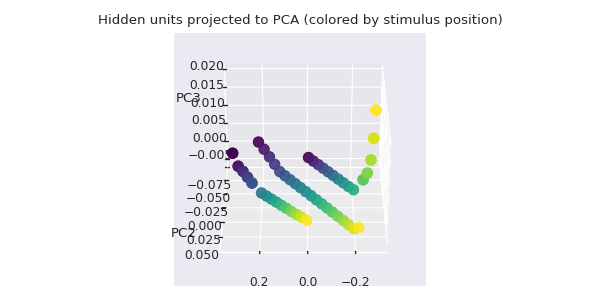

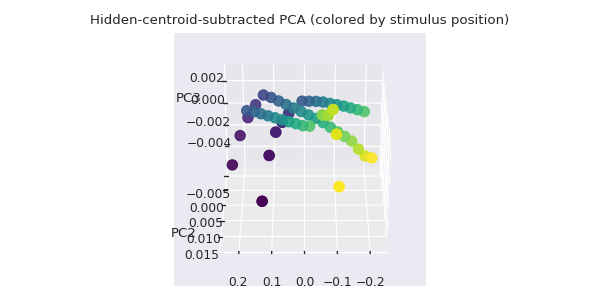

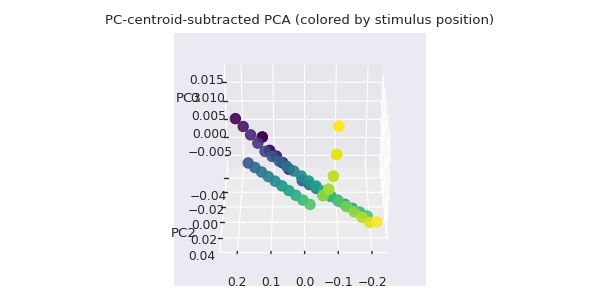

,boundary,bound_pos
0,0.25,0.251894
1,0.50,0.500000
2,0.75,0.748106


In [14]:
%matplotlib widget
sns.set(context='paper')

# average hidden activations across networks for each of the 60 trials
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# project to 3 PCs (plot 1)
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)

pca_df = pca_df.copy()
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# three green->yellow spectra (one per boundary)
cond_cmaps = {
    0.25: plt.cm.viridis_r,
    0.50: plt.cm.viridis_r,
    0.75: plt.cm.viridis_r,
}

# ── View angle (tweak these) ──────────────────────────────────────────────────
view_elev = 30   # elevation in degrees (default matplotlib: 30)
view_azim = -270   # azimuth  in degrees (default matplotlib: -60)

# plot 1: PCA with color encoding stimulus position within each condition
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    norm = Normalize(vmin=cond_df['stim'].min(), vmax=cond_df['stim'].max())
    colors = cond_cmaps[bound](norm(cond_df['stim'].values))

    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, label=f'b={bound:.2f}')
ax.set_title('Hidden units projected to PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
# ax.legend(loc='best')
plt.tight_layout()
plt.show()

# plot 2: subtract per-condition centroid in hidden-unit space, then project
hidden_centered = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    centroid = hidden_mean[idx].mean(axis=0)          # [10] mean hidden vec
    hidden_centered[idx] = hidden_mean[idx] - centroid

pca2 = PCA(n_components=3)
pcs2 = pca2.fit_transform(hidden_centered)

pca_df['PC1_c'] = pcs2[:, 0]
pca_df['PC2_c'] = pcs2[:, 1]
pca_df['PC3_c'] = pcs2[:, 2]

shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = cond_cmaps[bound](shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_c'], cond_df['PC2_c'], cond_df['PC3_c'], c=colors, s=55, alpha=0.9, label=f'b={bound:.2f} centered')

ax.set_title('Hidden-centroid-subtracted PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
plt.tight_layout()
plt.show()

# plot 3: subtract per-condition centroid in PC space (not hidden space)
pca3 = PCA(n_components=3)
pcs3 = pca3.fit_transform(hidden_mean)  # project original (uncentered) hidden to PC space

pcs3_centered = pcs3.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    centroid_pc = pcs3[idx].mean(axis=0)  # [3] mean in PC space
    pcs3_centered[idx] = pcs3[idx] - centroid_pc

pca_df['PC1_pcc'] = pcs3_centered[:, 0]
pca_df['PC2_pcc'] = pcs3_centered[:, 1]
pca_df['PC3_pcc'] = pcs3_centered[:, 2]

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = cond_cmaps[bound](shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, label=f'b={bound:.2f} PC-centered')

ax.set_title('PC-centroid-subtracted PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
plt.tight_layout()
plt.show()

pd.DataFrame({'boundary': list(bound_pos.keys()), 'bound_pos': list(bound_pos.values())})